We `FermionToQubitMapping` module allows to take circuits and operators in the Majorana basis and map them to a spin system using a fermions to qubits mapping. So far only the Jordan-Wigner mapping is implemented.

This allows two things:
1) use PauliPropagation.jl to simulate the circuit instead
2) the `majoranapropagation2yao` allows to use the Yao.jl statevector simulator to benchmark the output of MP against a statevector simulator

We give examples of both usages below

In [39]:
using Revise
using MajoranaPropagation
using PauliPropagation
using MajoranaPropagation.FermionToQubitMappings
using Yao 

In [40]:
n_sites_x = 4
n_sites = n_sites_x * n_sites_x
is_spinful = false 
topo = rectangletopology(n_sites_x, n_sites_x; periodic=true)

t = 1.
V = 1.
dt = 0.1 
n_layers = 5

5

In [41]:
circ_mp = FermionicRotation[]
thetas_mp = Float64[]

for pair in topo
    push!(circ_mp, FermionicRotation(:hop, pair))
    push!(thetas_mp, t * dt)
end

for pair in topo
    push!(circ_mp, FermionicRotation(:nn, pair))
    push!(thetas_mp, t * dt)
end

circ_pp, thetas_pp = JordanWigner(n_sites, is_spinful, circ_mp, thetas_mp)
circ_yao = majoranapropagation2yao(n_sites, is_spinful, circ_mp, thetas_mp);

In [ ]:
obs_mp = MajoranaSum(n_sites, :n, 2)
obs_pp = JordanWigner(obs_mp)
obs_yao = majoranapropagation2yao(obs_mp)

occupied_sites = 1:(n_sites ÷ 2)
fock_state = FockState(n_sites, occupied_sites)

yao_psi = zero_state(n_sites)
state_prep = chain(n_sites, put(site => Yao.X) for site in occupied_sites)
Yao.apply!(yao_psi, state_prep)


mp_res = zeros(n_layers)
pp_res = zeros(n_layers)
yao_res = zeros(n_layers)

min_abs_coeff = 1.e-5

for k = 1:n_layers
    # Majorana propagation
    propagate!(circ_mp, obs_mp, thetas_mp; min_abs_coeff)
    mp_res[k] = overlapwithfock(obs_mp, fock_state)

    # Pauli propagation
    propagate!(circ_pp, obs_pp, thetas_pp; min_abs_coeff)
    pp_res[k] = overlapwithcomputational(obs_pp, occupied_sites)

    # Yao statevector
    Yao.apply!(yao_psi, circ_yao)
    yao_res[k] = Yao.expect(obs_yao, yao_psi)
end

┌ Warning: Skipped marker arg cirle.
└ @ Plots /Users/Matteo/.julia/packages/Plots/GIume/src/args.jl:1155
┌ Warning: Skipped marker arg cirle.
└ @ Plots /Users/Matteo/.julia/packages/Plots/GIume/src/args.jl:1155
┌ Warning: Skipped marker arg cirle.
└ @ Plots /Users/Matteo/.julia/packages/Plots/GIume/src/args.jl:1155


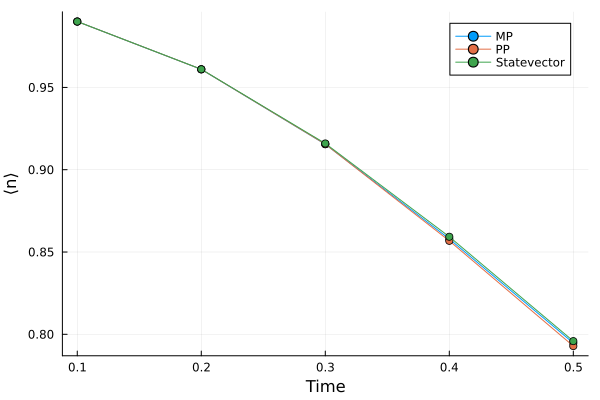

In [45]:
using Plots 
Plots.plot((1:n_layers) .* dt, mp_res, m=:cirle, label="MP", xlabel="Time", ylabel="⟨n⟩")
Plots.plot!((1:n_layers) .* dt, pp_res, m=:cirle, label="PP")
Plots.plot!((1:n_layers) .* dt, yao_res, m=:cirle, label="Statevector")